In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

In [3]:
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm.auto import tqdm
from torchmetrics.image import PeakSignalNoiseRatio as PSNR
from torchmetrics import MetricTracker

/home/pti/anaconda3/envs/snf/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from data_cohort import CohortDataset, resolve_cohort_image_paths
from network import AlpineStrainer
from metrics import psnr, ssim

## Config

In [5]:
# --- reproducibility ---
GLOBAL_SEED = 1


def set_global_seed(seed: int = GLOBAL_SEED) -> None:
    random.seed(int(seed))
    np.random.seed(int(seed) % (2**32 - 1))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed(GLOBAL_SEED)

# --- data ---
CELEBA_DIR   = "data/celeba/img_align_celeba"  # relative to repo root
N_TRAIN      = 10    # number of CelebA images to train on
CELEBA_START = 1     # first image index (000001.jpg)
N_VAL        = 10     # held-out images for generalisation test

# --- model (matches alpine Strainer notebook defaults) ---
HIDDEN_FEATURES  = 256
HIDDEN_LAYERS    = 6
NUM_SHARED_LAYERS = 5   # → 1 decoder layer per image (same as Alpine)
OMEGA            = 30.0

# --- training ---
EPOCHS_TRAIN = 5001   # full-grid steps, matching Alpine notebook
EPOCHS_VAL   = 2000   # steps to fit a new decoder on a held-out image
LR           = 1e-4   # Adam, matching Alpine compile() default

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE  = torch.float32
print(f"Device: {DEVICE}")
print(f"Global seed: {GLOBAL_SEED}")

Device: cuda
Global seed: 1


## Load CelebA training images

In [6]:
data_cfg_train = {
    "celeba_dir": CELEBA_DIR,
    "celeba_start": CELEBA_START,
    "max_images": N_TRAIN,
}
train_paths = resolve_cohort_image_paths(data_cfg_train)
print(f"Train paths ({len(train_paths)}):")
for p in train_paths:
    print(" ", p)

Train paths (10):
  /home/pti/Documents/git/sparse_inr/data/celeba/img_align_celeba/000001.jpg
  /home/pti/Documents/git/sparse_inr/data/celeba/img_align_celeba/000002.jpg
  /home/pti/Documents/git/sparse_inr/data/celeba/img_align_celeba/000003.jpg
  /home/pti/Documents/git/sparse_inr/data/celeba/img_align_celeba/000004.jpg
  /home/pti/Documents/git/sparse_inr/data/celeba/img_align_celeba/000005.jpg
  /home/pti/Documents/git/sparse_inr/data/celeba/img_align_celeba/000006.jpg
  /home/pti/Documents/git/sparse_inr/data/celeba/img_align_celeba/000007.jpg
  /home/pti/Documents/git/sparse_inr/data/celeba/img_align_celeba/000008.jpg
  /home/pti/Documents/git/sparse_inr/data/celeba/img_align_celeba/000009.jpg
  /home/pti/Documents/git/sparse_inr/data/celeba/img_align_celeba/000010.jpg


In [7]:
ds = CohortDataset(train_paths)
H, W = ds.img_shape
C = ds.channels
print(f"Image shape: {H}x{W}, channels: {C}, n_images: {ds.n_images}")

# coords: (N_pixels, 2)  —  same as train_strainer.py
coords = ds.coords.to(device=DEVICE, dtype=DTYPE)
print(f"coords.shape: {coords.shape}")

# targets: (N_pixels, n_img, C)  —  permute from (n_img, N_pixels, C)
targets = ds._flat_values.permute(1, 0, 2).to(device=DEVICE, dtype=DTYPE)
print(f"targets.shape: {targets.shape}")

Image shape: 218x178, channels: 3, n_images: 10
coords.shape: torch.Size([38804, 2])
targets.shape: torch.Size([38804, 10, 3])


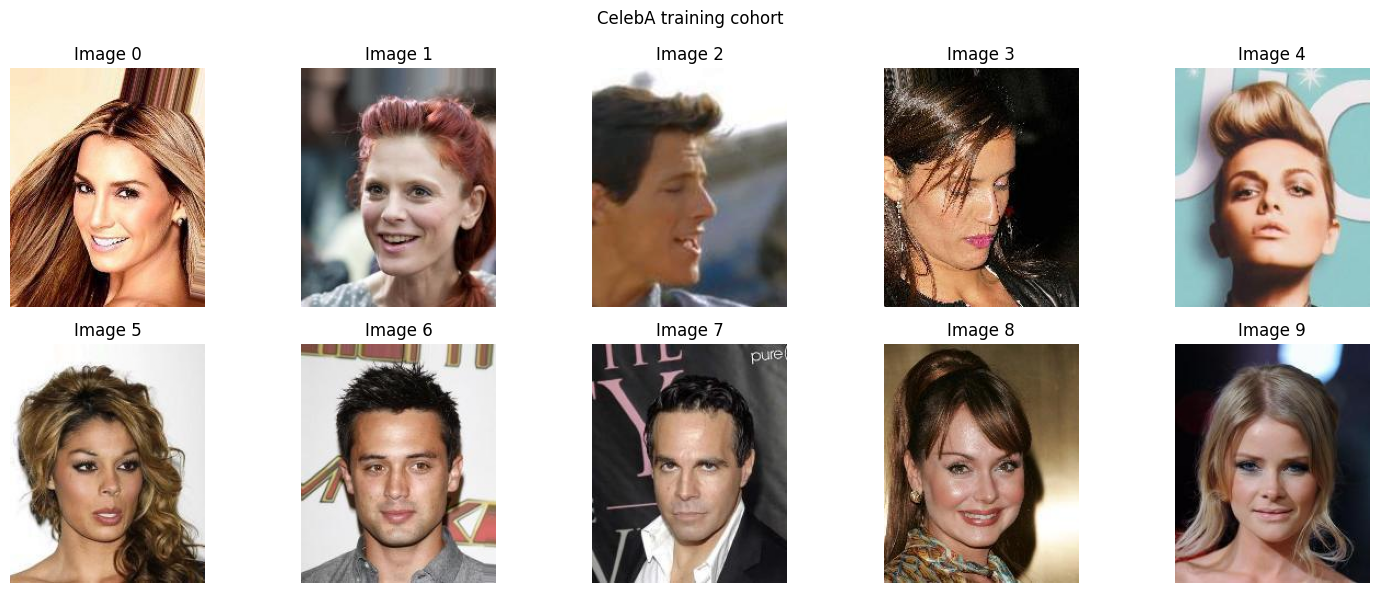

In [8]:
# Visualise the training images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for k, ax in enumerate(axes.flat):
    if k >= ds.n_images:
        ax.axis("off")
        continue
    img = ds.get_image_tensor(k).numpy()
    ax.imshow(img if C == 3 else img[:, :, 0], cmap=(None if C == 3 else "gray"))
    ax.set_title(f"Image {k}")
    ax.axis("off")
plt.suptitle("CelebA training cohort")
plt.tight_layout()
plt.show()

## Build Strainer

In [9]:
strainer_model = AlpineStrainer(
    in_features=2,
    hidden_features=HIDDEN_FEATURES,
    hidden_layers=HIDDEN_LAYERS,
    out_features=C,
    num_shared_layers=NUM_SHARED_LAYERS,
    num_decoders=N_TRAIN,
    omegas=[OMEGA],
    bias=True,
).to(device=DEVICE, dtype=DTYPE)

print(strainer_model)

AlpineStrainer(
  (encoder): ModuleList(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): _AlpineSine()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): _AlpineSine()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): _AlpineSine()
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): _AlpineSine()
    (8): Linear(in_features=256, out_features=256, bias=True)
    (9): _AlpineSine()
  )
  (decoder): ModuleList(
    (0-9): 10 x ModuleList(
      (0): Linear(in_features=256, out_features=3, bias=True)
    )
  )
)


In [10]:
# Sanity-check forward pass
with torch.no_grad():
    test_out = strainer_model(coords)["output"]
print(f"Forward output shape: {test_out.shape}")  # (N_pixels, n_img, C)

Forward output shape: torch.Size([38804, 10, 3])


## Phase 1 — Train on cohort

In [ ]:
import torch.nn as nn

optimizer  = torch.optim.Adam(strainer_model.parameters(), lr=LR)
criterion  = nn.MSELoss()
loss_history: list[float] = []

pbar = tqdm(range(EPOCHS_TRAIN), desc="train strainer")
for it in pbar:
    strainer_model.train()
    optimizer.zero_grad(set_to_none=True)

    pred = strainer_model(coords)["output"]   # (N_pixels, n_img, C)
    loss = criterion(pred, targets)

    loss.backward()
    optimizer.step()

    loss_val = float(loss.item())
    loss_history.append(loss_val)
    if it % 100 == 0:
        pbar.set_postfix(loss=f"{loss_val:.6f}")

train strainer:  71%|███████   | 3547/5001 [01:18<00:31, 45.48it/s, loss=0.000523]

In [ ]:
plt.figure(figsize=(9, 3))
plt.semilogy(loss_history)
plt.xlabel("iteration")
plt.ylabel("MSE loss (log scale)")
plt.title("Strainer training loss")
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate and visualise training reconstructions
strainer_model.eval()
with torch.no_grad():
    pred_all = strainer_model(coords)["output"].cpu()  # (N_pixels, n_img, C)

fig, axes = plt.subplots(N_TRAIN, 2, figsize=(6, 3 * N_TRAIN))
for k in range(N_TRAIN):
    gt_img = ds.get_image_tensor(k).numpy()
    pred_img = pred_all[:, k, :].reshape(H, W, C).clamp(0, 1).numpy()

    show_gt   = gt_img   if C == 3 else gt_img[:, :, 0]
    show_pred = pred_img if C == 3 else pred_img[:, :, 0]
    cmap = None if C == 3 else "gray"

    p = psnr(
        torch.from_numpy(pred_img).clamp(0, 1),
        torch.from_numpy(gt_img),
    ).item()

    axes[k, 0].imshow(show_gt, cmap=cmap)
    axes[k, 0].set_title(f"GT {k}")
    axes[k, 0].axis("off")
    axes[k, 1].imshow(show_pred, cmap=cmap)
    axes[k, 1].set_title(f"Pred {k}  PSNR={p:.2f} dB")
    axes[k, 1].axis("off")

plt.title("Train reconstructions after Phase 1")
plt.tight_layout()
plt.show()

## Phase 2 — Generalise to held-out images

Mirror the Alpine notebook: build a new single-decoder Strainer, copy the trained encoder weights, then call `fit_signal` on a fresh held-out image.

The encoder weights are **not frozen** here (same as Alpine). For a proper linear-probe variant see `reconstruct_strainer.py`.

In [ ]:
# Load held-out val images (immediately after the train cohort by index)
data_cfg_val = {
    "celeba_dir": CELEBA_DIR,
    "celeba_start": CELEBA_START + N_TRAIN,
    "max_images": N_VAL,
}
val_paths = resolve_cohort_image_paths(data_cfg_val)
print(f"Val paths ({len(val_paths)}):")
for p in val_paths:
    print(" ", p)

In [ ]:
def fit_new_decoder(
    trained_strainer: AlpineStrainer,
    coords: torch.Tensor,
    target: torch.Tensor,    # (N_pixels, C)
    n_iters: int = EPOCHS_VAL,
    lr: float = LR,
    seed: int = GLOBAL_SEED,
) -> AlpineStrainer:
    """Alpine-style generalisation: copy encoder, attach a fresh single-image decoder,
    fine-tune all parameters with Adam (encoder not frozen, matching Alpine notebook)."""
    set_global_seed(seed)
    strainer_test = AlpineStrainer(
        in_features=trained_strainer.in_features,
        hidden_features=trained_strainer.hidden_features,
        hidden_layers=trained_strainer.hidden_layers,
        out_features=trained_strainer.out_features,
        num_shared_layers=trained_strainer.num_shared_layers,
        num_decoders=1,
        omegas=trained_strainer._omegas,
        bias=True,
    ).to(device=coords.device, dtype=coords.dtype)

    # Copy encoder weights (matching alpine load_encoder_weights)
    strainer_test.load_encoder_weights(trained_strainer.encoder.state_dict())

    opt = torch.optim.Adam(strainer_test.parameters(), lr=lr)
    crit = nn.MSELoss()

    # target for the single decoder: (N_pixels, 1, C)
    target_unsqueezed = target.unsqueeze(1)

    pbar = tqdm(range(n_iters), desc="  fit new decoder", leave=False)
    for _ in pbar:
        strainer_test.train()
        opt.zero_grad(set_to_none=True)
        pred = strainer_test(coords)["output"]   # (N_pixels, 1, C)
        loss = crit(pred, target_unsqueezed)
        loss.backward()
        opt.step()
        pbar.set_postfix(loss=f"{loss.item():.6f}")

    strainer_test.eval()
    return strainer_test

In [ ]:
ds_val = CohortDataset(val_paths)
H_v, W_v = ds_val.img_shape
C_v = ds_val.channels
coords_val = ds_val.coords.to(device=DEVICE, dtype=DTYPE)

fig, axes = plt.subplots(N_VAL, 2, figsize=(6, 3 * N_VAL))
if N_VAL == 1:
    axes = axes[np.newaxis, :]

for k in range(N_VAL):
    print(f"\nGeneralising to val image {k} ({val_paths[k].name}) ...")
    target_k = ds_val.flat_targets(k).to(device=DEVICE, dtype=DTYPE)  # (N_pixels, C)

    strainer_test = fit_new_decoder(strainer_model, coords_val, target_k)

    with torch.no_grad():
        pred_flat = strainer_test(coords_val)["output"][:, 0, :].cpu()  # (N_pixels, C)

    gt_img   = ds_val.get_image_tensor(k).numpy()
    pred_img = pred_flat.reshape(H_v, W_v, C_v).clamp(0, 1).numpy()

    show_gt   = gt_img   if C_v == 3 else gt_img[:, :, 0]
    show_pred = pred_img if C_v == 3 else pred_img[:, :, 0]
    cmap = None if C_v == 3 else "gray"

    p = psnr(
        torch.from_numpy(pred_img).clamp(0, 1),
        torch.from_numpy(gt_img),
    ).item()
    s = ssim(
        torch.from_numpy(pred_img).clamp(0, 1),
        torch.from_numpy(gt_img),
    ).item()
    print(f"  PSNR={p:.2f} dB  SSIM={s:.4f}")

    axes[k, 0].imshow(show_gt, cmap=cmap)
    axes[k, 0].set_title(f"GT {k}")
    axes[k, 0].axis("off")
    axes[k, 1].imshow(show_pred, cmap=cmap)
    axes[k, 1].set_title(f"Pred {k}  PSNR={p:.2f} dB")
    axes[k, 1].axis("off")

plt.title("Held-out generalisation (Phase 2 — encoder warm-start)")
plt.tight_layout()
plt.show()

## (Optional) Encoder feature PCA

Visualise the shared encoder's representation across all training images — analogous to `alpine.vis.pca`.

In [ ]:
from sklearn.decomposition import PCA

strainer_model.eval()
with torch.no_grad():
    feats = strainer_model.encode(coords).cpu().numpy()  # (N_pixels, hidden_features)

pca = PCA(n_components=3)
feats_pca = pca.fit_transform(feats)           # (N_pixels, 3)

# Normalise to [0, 1] for display
feats_pca -= feats_pca.min(axis=0)
feats_pca /= feats_pca.max(axis=0) + 1e-8

pca_img = feats_pca.reshape(H, W, 3)
plt.figure(figsize=(5, 5))
plt.imshow(pca_img)
plt.title("PCA of shared encoder features (3 components → RGB)")
plt.axis("off")
plt.tight_layout()
plt.show()

## Save / load checkpoint

In [ ]:
import json
from pathlib import Path

ckpt_dir = Path("outputs/strainer_celeba_notebook")
ckpt_dir.mkdir(parents=True, exist_ok=True)

model_cfg = {
    "in_features": strainer_model.in_features,
    "hidden_features": strainer_model.hidden_features,
    "hidden_layers": strainer_model.hidden_layers,
    "out_features": strainer_model.out_features,
    "num_shared_layers": strainer_model.num_shared_layers,
    "strainer_num_images": strainer_model.num_decoders,
    "omegas": strainer_model._omegas,
    "bias": True,
}

torch.save(
    {
        "state_dict": strainer_model.state_dict(),
        "model_cfg": model_cfg,
        "global_step": EPOCHS_TRAIN,
        "iteration": EPOCHS_TRAIN - 1,
    },
    ckpt_dir / "last.pt",
)
print(f"Checkpoint saved to {ckpt_dir / 'last.pt'}")


## Strainer layer transfer

This is the transfer baseline before adding SAE. For `TRANSFER_DEPTH = k`, copy the trained Strainer, freeze shared encoder blocks `0..k`, reinitialize the encoder blocks above `k` plus the single-image decoder, then fit the target image.

`TRANSFER_DEPTH = -1` is the scratch baseline: same architecture, random initialization, no transferred frozen blocks.

### Transfer Settings

Configure the freeze depths, training budget, optimizer settings, seed, and source decoder head used for the plain Strainer layer-transfer baseline.

In [ ]:
from strainer_layer_transfer import apply_l_freeze

# -1 = scratch baseline; 0..NUM_SHARED_LAYERS-1 freeze encoder blocks through that depth.
# TRANSFER_DEPTHS = [-1] + list(range(NUM_SHARED_LAYERS))
TRANSFER_DEPTHS = list(range(NUM_SHARED_LAYERS))
TRANSFER_EPOCHS = EPOCHS_VAL
TRANSFER_LR = LR
TRANSFER_BATCH_SIZE = coords.shape[0]  # full-grid by default; reduce if needed
TRANSFER_REINIT_SEED = GLOBAL_SEED
TRANSFER_TRAIN_SEED = GLOBAL_SEED
TRANSFER_DECODER_SOURCE_IDX = 0

print(f"Layer-transfer depths: {TRANSFER_DEPTHS}")

### Transfer Helper Functions

Build a single-decoder copy of the trained Strainer, apply the freeze/reinitialization policy, and optimize the trainable layers on a target image.

In [ ]:
def make_single_decoder_strainer_copy(
    trained_strainer: AlpineStrainer,
    decoder_source_idx: int = 0,
) -> AlpineStrainer:
    """Copy the shared encoder and one decoder head into a single-image Strainer."""
    if not (0 <= decoder_source_idx < trained_strainer.num_decoders):
        raise IndexError(
            f"decoder_source_idx={decoder_source_idx} out of range "
            f"for {trained_strainer.num_decoders} decoders"
        )

    copied = AlpineStrainer(
        in_features=trained_strainer.in_features,
        hidden_features=trained_strainer.hidden_features,
        hidden_layers=trained_strainer.hidden_layers,
        out_features=trained_strainer.out_features,
        num_shared_layers=trained_strainer.num_shared_layers,
        num_decoders=1,
        omegas=trained_strainer._omegas,
        bias=True,
    ).to(device=next(trained_strainer.parameters()).device, dtype=next(trained_strainer.parameters()).dtype)

    copied.encoder.load_state_dict(trained_strainer.encoder.state_dict())
    copied.decoder[0].load_state_dict(trained_strainer.decoder[decoder_source_idx].state_dict())
    return copied


def prepare_layer_transfer_model(
    trained_strainer: AlpineStrainer,
    *,
    transfer_depth: int,
    decoder_source_idx: int = 0,
    reinit_seed: int = 0,
) -> AlpineStrainer:
    """Copy source weights, apply freeze/reinit policy, and return a single-head model."""
    set_global_seed(reinit_seed)

    transfer_model = make_single_decoder_strainer_copy(
        trained_strainer,
        decoder_source_idx=decoder_source_idx,
    )
    apply_l_freeze(
        transfer_model,
        transfer_depth,
        reinit_seed=reinit_seed,
        is_ffmlp=False,
    )
    return transfer_model


def fit_layer_transfer(
    transfer_model: AlpineStrainer,
    coords: torch.Tensor,
    target: torch.Tensor,
    *,
    n_epochs: int,
    lr: float,
    batch_size: int,
    train_seed: int = 0,
) -> tuple[AlpineStrainer, list[float]]:
    params = [p for p in transfer_model.parameters() if p.requires_grad]
    if not params:
        raise ValueError("No trainable parameters in layer-transfer model")

    opt = torch.optim.Adam(params, lr=lr)
    crit = torch.nn.MSELoss()
    target_unsqueezed = target.unsqueeze(1)
    n = coords.shape[0]
    bs = min(batch_size, n)
    history: list[float] = []

    pbar = tqdm(range(n_epochs), desc="layer transfer")
    for epoch in pbar:
        g = torch.Generator(device=coords.device)
        g.manual_seed(int(train_seed) + epoch)
        perm = torch.randperm(n, generator=g, device=coords.device)

        epoch_loss = 0.0
        seen = 0
        transfer_model.train()
        for start in range(0, n, bs):
            idx = perm[start : start + bs]
            pred = transfer_model(coords[idx])["output"]
            loss = crit(pred, target_unsqueezed[idx])

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            epoch_loss += float(loss.item()) * idx.numel()
            seen += idx.numel()

        mean_loss = epoch_loss / max(seen, 1)
        history.append(mean_loss)
        if epoch % 25 == 0 or epoch == n_epochs - 1:
            pbar.set_postfix(loss=f"{mean_loss:.6f}")

    transfer_model.eval()
    return transfer_model, history

### Run One Layer-Transfer Experiment

Choose one held-out validation image and one freeze depth, then fine-tune the transferred Strainer and visualize the reconstruction.

In [ ]:
TRANSFER_VAL_INDEX = 1  # validate on the first heldout image
TRANSFER_DEPTH = 1  # try -1, 0, 1, ..., NUM_SHARED_LAYERS-1

target_transfer = ds_val.flat_targets(TRANSFER_VAL_INDEX).to(device=DEVICE, dtype=DTYPE)
transfer_model = prepare_layer_transfer_model(
    strainer_model,
    transfer_depth=TRANSFER_DEPTH,
    decoder_source_idx=TRANSFER_DECODER_SOURCE_IDX,
    reinit_seed=TRANSFER_REINIT_SEED,
)

transfer_model, transfer_loss = fit_layer_transfer(
    transfer_model,
    coords_val,
    target_transfer,
    n_epochs=TRANSFER_EPOCHS,
    lr=TRANSFER_LR,
    batch_size=TRANSFER_BATCH_SIZE,
    train_seed=TRANSFER_TRAIN_SEED,
)
strainer_test = fit_new_decoder(strainer_model, coords_val, target_transfer)

with torch.no_grad():
    pred_transfer_flat = transfer_model(coords_val)["output"][:, 0, :].cpu()
    pred_strainer_flat = strainer_test(coords_val)["output"][:, 0, :].cpu()

gt_transfer = ds_val.get_image_tensor(TRANSFER_VAL_INDEX).numpy()
pred_transfer = pred_transfer_flat.reshape(H_v, W_v, C_v).clamp(0, 1).numpy()
pred_strainer = pred_strainer_flat.reshape(H_v, W_v, C_v).clamp(0, 1).numpy()

p_transfer = psnr(
    torch.from_numpy(pred_transfer),
    torch.from_numpy(gt_transfer),
).item()
s_transfer = ssim(
    torch.from_numpy(pred_transfer),
    torch.from_numpy(gt_transfer),
).item()
p_strainer = psnr(
    torch.from_numpy(pred_strainer),
    torch.from_numpy(gt_transfer),
).item()
s_strainer = ssim(
    torch.from_numpy(pred_strainer),
    torch.from_numpy(gt_transfer),
).item()
print(
    f"Layer transfer depth={TRANSFER_DEPTH}, val image={TRANSFER_VAL_INDEX}: "
    f"PSNR={p_transfer:.2f} dB, SSIM={s_transfer:.4f}"
)
print(
    f"Strainer held-out test, val image={TRANSFER_VAL_INDEX}: "
    f"PSNR={p_strainer:.2f} dB, SSIM={s_strainer:.4f}"
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
show_gt = gt_transfer if C_v == 3 else gt_transfer[:, :, 0]
show_transfer = pred_transfer if C_v == 3 else pred_transfer[:, :, 0]
show_strainer = pred_strainer if C_v == 3 else pred_strainer[:, :, 0]
cmap = None if C_v == 3 else "gray"
axes[0].imshow(show_gt, cmap=cmap)
axes[0].set_title("GT")
axes[0].axis("off")
axes[1].imshow(show_transfer, cmap=cmap)
axes[1].set_title(f"Transfer depth {TRANSFER_DEPTH}\nPSNR={p_transfer:.2f} dB")
axes[1].axis("off")
axes[2].imshow(show_strainer, cmap=cmap)
axes[2].set_title(f"Strainer held-out\nPSNR={p_strainer:.2f} dB")
axes[2].axis("off")
plt.suptitle("Held-out Strainer layer transfer")
plt.tight_layout()
plt.show()

### Optional Transfer Depth Sweep

Run the same transfer experiment for every freeze depth to see how much each prefix of the shared encoder helps. This is slow when enabled.

In [ ]:
# Optional: sweep all transfer depths on one held-out image.
# This is slower than the single-depth cell above because it fits one model per depth.
RUN_TRANSFER_DEPTH_SWEEP = True

if RUN_TRANSFER_DEPTH_SWEEP:
    transfer_sweep_results = []
    target_sweep = ds_val.flat_targets(TRANSFER_VAL_INDEX).to(device=DEVICE, dtype=DTYPE)
    gt_sweep = ds_val.get_image_tensor(TRANSFER_VAL_INDEX).numpy()

    for depth in TRANSFER_DEPTHS:
        print(f"\nRunning layer transfer depth={depth} ...")
        model_d = prepare_layer_transfer_model(
            strainer_model,
            transfer_depth=depth,
            decoder_source_idx=TRANSFER_DECODER_SOURCE_IDX,
            reinit_seed=TRANSFER_REINIT_SEED,
        )
        model_d, loss_d = fit_layer_transfer(
            model_d,
            coords_val,
            target_sweep,
            n_epochs=2000,
            lr=TRANSFER_LR,
            batch_size=TRANSFER_BATCH_SIZE,
            train_seed=TRANSFER_TRAIN_SEED,
        )

        with torch.no_grad():
            pred_d_flat = model_d(coords_val)["output"][:, 0, :].cpu()
        pred_d = pred_d_flat.reshape(H_v, W_v, C_v).clamp(0, 1).numpy()
        p_d = psnr(torch.from_numpy(pred_d).clamp(0, 1), torch.from_numpy(gt_sweep)).item()
        s_d = ssim(torch.from_numpy(pred_d).clamp(0, 1), torch.from_numpy(gt_sweep)).item()
        transfer_sweep_results.append(
            {"depth": depth, "psnr": p_d, "ssim": s_d, "final_loss": loss_d[-1]}
        )
        print(f"  PSNR={p_d:.2f} dB  SSIM={s_d:.4f}")

    labels = [str(r["depth"]) for r in transfer_sweep_results]
    psnrs = [r["psnr"] for r in transfer_sweep_results]
    plt.figure(figsize=(7, 3))
    plt.bar(labels, psnrs)
    plt.xlabel("transfer depth (-1 = scratch)")
    plt.ylabel("PSNR (dB)")
    plt.title(f"Layer-transfer sweep on val image {TRANSFER_VAL_INDEX}")
    plt.tight_layout()
    plt.show()

## SAE per-layer decomposition

Train one `TopKSAE` for each shared Strainer encoder depth. Depth `0` means activations after the first shared `(Linear + Sine)` block; depth `NUM_SHARED_LAYERS - 1` means the final shared encoder representation.

For each depth we measure activation reconstruction R² and image-space fidelity by decoding both true activations and SAE-reconstructed activations through the remaining Strainer layers and every training decoder.

### SAE Hyperparameters

Set which shared depths to decompose, the dictionary size, sparsity `k`, training budget, and output directory for per-layer SAE checkpoints.

In [ ]:
from pathlib import Path
import json

from sae import TopKSAE

SAE_DEPTHS = list(range(NUM_SHARED_LAYERS))
SAE_D_DICT = 4096
SAE_K = 32
SAE_STEPS = 10000
SAE_LR = 1e-4
SAE_WEIGHT_DECAY = 0.0
SAE_BATCH_SIZE = min(8192, coords.shape[0])
SAE_CHUNK_SIZE = 65536
SAE_TOP_N = 16
SAE_OUT_DIR = Path("outputs/strainer_celeba_notebook/sae_per_layer")
SAE_OUT_DIR.mkdir(parents=True, exist_ok=True)

print(
    f"Training Strainer SAEs for depths {SAE_DEPTHS}: "
    f"d_dict={SAE_D_DICT}, k={SAE_K}, steps={SAE_STEPS}"
)

### SAE Training Helpers

These functions collect hidden activations from one shared Strainer depth and fit a TopK sparse autoencoder to those activations.

In [ ]:
@torch.no_grad()
def collect_strainer_activations_at_depth(
    strainer: AlpineStrainer,
    coords: torch.Tensor,
    depth: int,
    chunk_size: int = SAE_CHUNK_SIZE,
) -> torch.Tensor:
    """Return activations after shared encoder depth `depth` on CPU."""
    if depth < 0 or depth >= strainer.num_shared_layers:
        raise ValueError(f"depth must be in 0..{strainer.num_shared_layers - 1}, got {depth}")

    end_idx = 2 * (depth + 1)
    chunks = []
    strainer.eval()
    for start in range(0, coords.shape[0], chunk_size):
        x = coords[start : start + chunk_size]
        for layer in strainer.encoder[:end_idx]:
            x = layer(x)
        chunks.append(x.detach().cpu())
    return torch.cat(chunks, dim=0)


def train_topk_sae_on_activations(
    activations: torch.Tensor,
    *,
    depth: int,
    d_dict: int = SAE_D_DICT,
    k: int = SAE_K,
    steps: int = SAE_STEPS,
    lr: float = SAE_LR,
    weight_decay: float = SAE_WEIGHT_DECAY,
    batch_size: int = SAE_BATCH_SIZE,
    seed: int = GLOBAL_SEED,
) -> tuple[TopKSAE, list[dict[str, float]]]:
    """Fit one TopKSAE to a fixed activation matrix."""
    set_global_seed(seed)
    d_model = activations.shape[-1]
    sae = TopKSAE(d_model=d_model, d_dict=d_dict, k=k).to(device=DEVICE, dtype=DTYPE)
    sae.pre_bias.data.copy_(activations.mean(dim=0).to(device=DEVICE, dtype=DTYPE))

    opt = torch.optim.AdamW(sae.parameters(), lr=lr, weight_decay=weight_decay)
    history: list[dict[str, float]] = []
    n = activations.shape[0]
    bs = min(batch_size, n)

    pbar = tqdm(range(steps), desc=f"train SAE depth {depth}")
    for step in pbar:
        idx = torch.randint(0, n, (bs,))
        batch = activations[idx].to(device=DEVICE, dtype=DTYPE)

        sae.train()
        losses = sae.loss(batch)
        losses["loss"].backward()
        opt.step()
        opt.zero_grad(set_to_none=True)
        sae._normalize_decoder()

        if step % 50 == 0 or step == steps - 1:
            sae.eval()
            with torch.no_grad():
                ss_res = 0.0
                ss_tot = 0.0
                mean = activations.mean(dim=0).to(device=DEVICE, dtype=DTYPE)
                l0_vals = []
                active = torch.zeros(d_dict, dtype=torch.bool, device=DEVICE)
                for start in range(0, n, SAE_CHUNK_SIZE):
                    full_batch = activations[start : start + SAE_CHUNK_SIZE].to(device=DEVICE, dtype=DTYPE)
                    x_hat, z = sae(full_batch)
                    ss_res += float((full_batch - x_hat).pow(2).sum().item())
                    ss_tot += float((full_batch - mean).pow(2).sum().item())
                    l0_vals.append((z > 0).float().sum(dim=-1).mean().item())
                    active |= (z > 0).any(dim=0)
                record = {
                    "step": float(step),
                    "r2": float(1.0 - ss_res / max(ss_tot, 1e-8)),
                    "l0": float(np.mean(l0_vals)),
                    "dead_frac": float((~active).float().mean().item()),
                }
            history.append(record)
            pbar.set_postfix(r2=f"{record['r2']:.4f}", dead=f"{record['dead_frac']:.1%}")

    sae.eval()
    return sae, history

### SAE Validation Helpers

These helpers measure whether SAE-reconstructed activations preserve the image output after passing through the remaining Strainer layers and decoder heads.

In [ ]:
@torch.no_grad()
def validate_strainer_sae_at_depth(
    strainer: AlpineStrainer,
    sae: TopKSAE,
    activations: torch.Tensor,
    targets: torch.Tensor,
    depth: int,
    chunk_size: int = SAE_CHUNK_SIZE,
) -> dict[str, object]:
    """Measure SAE activation R2 and image-space fidelity for every training decoder."""
    strainer.eval()
    sae.eval()
    remaining_encoder = strainer.encoder[2 * (depth + 1) :]

    true_tail_chunks = []
    sae_tail_chunks = []
    ss_res = 0.0
    mean = activations.mean(dim=0).to(device=DEVICE, dtype=DTYPE)
    ss_tot = float((activations.to(device=DEVICE, dtype=DTYPE) - mean).pow(2).sum().item())

    for start in range(0, activations.shape[0], chunk_size):
        act = activations[start : start + chunk_size].to(device=DEVICE, dtype=DTYPE)
        act_hat = sae.decode(sae.encode(act))
        ss_res += float((act - act_hat).pow(2).sum().item())

        x_true = act
        x_sae = act_hat
        for layer in remaining_encoder:
            x_true = layer(x_true)
            x_sae = layer(x_sae)
        true_tail_chunks.append(x_true.cpu())
        sae_tail_chunks.append(x_sae.cpu())

    true_tail = torch.cat(true_tail_chunks, dim=0)
    sae_tail = torch.cat(sae_tail_chunks, dim=0)
    val_r2 = 1.0 - ss_res / max(ss_tot, 1e-8)

    psnr_sae = []
    psnr_inr = []
    fidelity = []
    for img_idx in range(targets.shape[1]):
        gt = targets[:, img_idx, :].cpu().clamp(0, 1)
        pred_true_chunks = []
        pred_sae_chunks = []

        for start in range(0, true_tail.shape[0], chunk_size):
            x_true = true_tail[start : start + chunk_size].to(device=DEVICE, dtype=DTYPE)
            x_sae = sae_tail[start : start + chunk_size].to(device=DEVICE, dtype=DTYPE)
            for layer in strainer.decoder[img_idx]:
                x_true = layer(x_true)
                x_sae = layer(x_sae)
            pred_true_chunks.append(x_true.cpu())
            pred_sae_chunks.append(x_sae.cpu())

        pred_true = torch.cat(pred_true_chunks, dim=0).clamp(0, 1)
        pred_sae = torch.cat(pred_sae_chunks, dim=0).clamp(0, 1)
        p_inr = psnr(pred_true, gt).item()
        p_sae = psnr(pred_sae, gt).item()
        psnr_inr.append(p_inr)
        psnr_sae.append(p_sae)
        fidelity.append(p_sae / p_inr if p_inr > 1e-8 else 0.0)

    return {
        "depth": int(depth),
        "r2": float(val_r2),
        "mean_psnr_sae": float(np.mean(psnr_sae)),
        "mean_psnr_inr": float(np.mean(psnr_inr)),
        "mean_fidelity_ratio": float(np.mean(fidelity)),
        "psnr_sae_per_image": psnr_sae,
        "psnr_inr_per_image": psnr_inr,
        "fidelity_ratio_per_image": fidelity,
    }


@torch.no_grad()
def collect_sae_codes(
    sae: TopKSAE,
    activations: torch.Tensor,
    chunk_size: int = SAE_CHUNK_SIZE,
) -> torch.Tensor:
    """Encode all pixels into sparse SAE codes on CPU."""
    chunks = []
    sae.eval()
    for start in range(0, activations.shape[0], chunk_size):
        batch = activations[start : start + chunk_size].to(device=DEVICE, dtype=DTYPE)
        chunks.append(sae.encode(batch).cpu())
    return torch.cat(chunks, dim=0)

### Train SAEs For All Shared Depths

For each shared Strainer layer, collect the layer activations, train a `TopKSAE`, validate it through the remaining Strainer decoder path, and save `sae.pt` plus `sae_summary.json`.

In [ ]:
# Train one SAE per shared Strainer depth.
strainer_sae_by_depth: dict[int, TopKSAE] = {}
strainer_sae_activations_by_depth: dict[int, torch.Tensor] = {}
strainer_sae_histories: dict[int, list[dict[str, float]]] = {}
strainer_sae_summaries: list[dict[str, object]] = []

targets_cpu = targets.detach().cpu()

for depth in SAE_DEPTHS:
    print(f"\n=== Strainer SAE depth {depth} ===")
    acts_d = collect_strainer_activations_at_depth(
        strainer_model,
        coords,
        depth,
        chunk_size=SAE_CHUNK_SIZE,
    )
    print(f"activations: {tuple(acts_d.shape)}")

    sae_d, hist_d = train_topk_sae_on_activations(
        acts_d,
        depth=depth,
    )
    summary_d = validate_strainer_sae_at_depth(
        strainer_model,
        sae_d,
        acts_d,
        targets_cpu,
        depth,
    )
    summary_d.update(
        {
            "d_model": int(sae_d.d_model),
            "d_dict": int(sae_d.d_dict),
            "k": int(sae_d.k),
            "final_train_r2": float(hist_d[-1]["r2"]),
            "final_dead_frac": float(hist_d[-1]["dead_frac"]),
        }
    )

    depth_dir = SAE_OUT_DIR / f"depth_{depth}"
    depth_dir.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "sae_state_dict": sae_d.state_dict(),
            "depth": depth,
            "d_model": sae_d.d_model,
            "d_dict": sae_d.d_dict,
            "k": sae_d.k,
            "cfg": {
                "source": "strainer_sae_decomposition.ipynb",
                "hidden_features": HIDDEN_FEATURES,
                "num_shared_layers": NUM_SHARED_LAYERS,
                "epochs_train": EPOCHS_TRAIN,
            },
            "summary": summary_d,
            "history": hist_d,
        },
        depth_dir / "sae.pt",
    )
    with open(depth_dir / "sae_summary.json", "w") as f:
        json.dump(summary_d, f, indent=2)

    strainer_sae_by_depth[depth] = sae_d
    strainer_sae_activations_by_depth[depth] = acts_d
    strainer_sae_histories[depth] = hist_d
    strainer_sae_summaries.append(summary_d)

    print(
        f"depth {depth}: R2={summary_d['r2']:.4f}, "
        f"SAE PSNR={summary_d['mean_psnr_sae']:.2f} dB, "
        f"INR PSNR={summary_d['mean_psnr_inr']:.2f} dB, "
        f"fidelity={summary_d['mean_fidelity_ratio']:.3f}"
    )

### Compare SAE Quality Across Depths

Plot activation reconstruction R², image-space PSNR, and the SAE/INR fidelity ratio for all trained SAE depths.

In [ ]:
# Summary plots across depths.
summary_depths = [int(s["depth"]) for s in strainer_sae_summaries]
summary_r2 = [float(s["r2"]) for s in strainer_sae_summaries]
summary_psnr = [float(s["mean_psnr_sae"]) for s in strainer_sae_summaries]
summary_inr_psnr = [float(s["mean_psnr_inr"]) for s in strainer_sae_summaries]
summary_fidelity = [float(s["mean_fidelity_ratio"]) for s in strainer_sae_summaries]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(summary_depths, summary_r2, marker="o")
axes[0].set_title("Activation reconstruction")
axes[0].set_xlabel("Strainer depth")
axes[0].set_ylabel("R²")
axes[0].grid(alpha=0.25)

axes[1].plot(summary_depths, summary_inr_psnr, marker="o", label="true activations")
axes[1].plot(summary_depths, summary_psnr, marker="o", label="SAE activations")
axes[1].set_title("Image-space reconstruction")
axes[1].set_xlabel("Strainer depth")
axes[1].set_ylabel("mean PSNR (dB)")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].plot(summary_depths, summary_fidelity, marker="o")
axes[2].axhline(1.0, color="black", linewidth=1, linestyle="--")
axes[2].set_title("SAE / INR PSNR ratio")
axes[2].set_xlabel("Strainer depth")
axes[2].set_ylabel("fidelity ratio")
axes[2].grid(alpha=0.25)

plt.suptitle("Strainer SAE per-layer decomposition summary")
plt.tight_layout()
plt.show()

strainer_sae_summaries

### Visualize Sparse Feature Maps

Select one SAE depth and plot the most active dictionary features as spatial maps over the image grid.

In [ ]:
# Visualize the most active sparse features at one depth as spatial maps.
SAE_VIS_DEPTH = NUM_SHARED_LAYERS - 1
SAE_VIS_TOP_N = min(SAE_TOP_N, SAE_D_DICT)

sae_vis = strainer_sae_by_depth[SAE_VIS_DEPTH]
acts_vis = strainer_sae_activations_by_depth[SAE_VIS_DEPTH]
z_vis = collect_sae_codes(sae_vis, acts_vis)
mean_abs_z = z_vis.abs().mean(dim=0)
top_features = torch.argsort(mean_abs_z, descending=True)[:SAE_VIS_TOP_N].tolist()

ncols = 4
nrows = math.ceil((SAE_VIS_TOP_N + 1) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))
axes = np.array(axes).reshape(-1)

train_img_idx = 4
base_img = ds.get_image_tensor(4).numpy()
axes[0].imshow(base_img if C == 3 else base_img[:, :, 0], cmap=(None if C == 3 else "gray"))
axes[0].set_title(f"train image {train_img_idx}")
axes[0].axis("off")

for ax_idx, feat_idx in enumerate(top_features, start=1):
    ax = axes[ax_idx]
    fmap = z_vis[:, feat_idx].reshape(H, W).numpy()
    vmax = np.percentile(fmap, 99.0)
    im = ax.imshow(fmap, cmap="viridis", vmin=0, vmax=(vmax if vmax > 0 else None))
    ax.set_title(f"feature {feat_idx}\nmean |z|={mean_abs_z[feat_idx]:.3g}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes[SAE_VIS_TOP_N + 1 :]:
    ax.axis("off")

plt.suptitle(f"Top SAE features at Strainer depth {SAE_VIS_DEPTH}")
plt.tight_layout()
plt.show()

### Reconstruct Through One SAE Layer

Render one training image through the normal Strainer tail and through the SAE-reconstructed activations at a selected depth. This is a sanity check before atom ablation.

In [ ]:
# Optional: reconstruct one training image using true vs SAE-reconstructed activations at one depth.
SAE_RECON_DEPTH = SAE_VIS_DEPTH
SAE_RECON_IMAGE_INDEX = 4

sae_recon = strainer_sae_by_depth[SAE_RECON_DEPTH]
acts_recon = strainer_sae_activations_by_depth[SAE_RECON_DEPTH]
remaining_encoder = strainer_model.encoder[2 * (SAE_RECON_DEPTH + 1) :]

true_chunks = []
sae_chunks = []
with torch.no_grad():
    for start in range(0, acts_recon.shape[0], SAE_CHUNK_SIZE):
        act = acts_recon[start : start + SAE_CHUNK_SIZE].to(device=DEVICE, dtype=DTYPE)
        act_hat = sae_recon.decode(sae_recon.encode(act))
        x_true = act
        x_sae = act_hat
        for layer in remaining_encoder:
            x_true = layer(x_true)
            x_sae = layer(x_sae)
        for layer in strainer_model.decoder[SAE_RECON_IMAGE_INDEX]:
            x_true = layer(x_true)
            x_sae = layer(x_sae)
        true_chunks.append(x_true.cpu())
        sae_chunks.append(x_sae.cpu())

pred_true = torch.cat(true_chunks, dim=0).reshape(H, W, C).clamp(0, 1)
pred_sae = torch.cat(sae_chunks, dim=0).reshape(H, W, C).clamp(0, 1)
gt_recon = ds.get_image_tensor(SAE_RECON_IMAGE_INDEX)

p_true = psnr(pred_true, gt_recon).item()
p_sae = psnr(pred_sae, gt_recon).item()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
show_gt = gt_recon.numpy() if C == 3 else gt_recon.numpy()[:, :, 0]
show_true = pred_true.numpy() if C == 3 else pred_true.numpy()[:, :, 0]
show_sae = pred_sae.numpy() if C == 3 else pred_sae.numpy()[:, :, 0]
cmap = None if C == 3 else "gray"
axes[0].imshow(show_gt, cmap=cmap)
axes[0].set_title("GT")
axes[0].axis("off")
axes[1].imshow(show_true, cmap=cmap)
axes[1].set_title(f"Strainer path\nPSNR={p_true:.2f} dB")
axes[1].axis("off")
axes[2].imshow(show_sae, cmap=cmap)
axes[2].set_title(f"SAE path depth {SAE_RECON_DEPTH}\nPSNR={p_sae:.2f} dB")
axes[2].axis("off")
plt.suptitle("Image reconstruction through SAE-decomposed layer")
plt.tight_layout()
plt.show()

## Ablate one SAE atom

Choose a trained SAE depth and one dictionary atom, set that atom's sparse code to zero for every pixel, then decode through the remaining Strainer layers and the selected image decoder.

Use this to inspect what a single sparse feature contributes in image space.

### Choose The Atom To Remove

Pick a depth, image, and atom. Leaving `ABLATE_ATOM = None` automatically ablates the most active atom at the selected depth.

In [ ]:
# Atom ablation controls.
ABLATE_DEPTH = SAE_VIS_DEPTH
ABLATE_IMAGE_INDEX = 4

# If None, use the most active atom at ABLATE_DEPTH. Otherwise set an integer atom id.
ABLATE_ATOM = None
ABLATE_CHUNK_SIZE = SAE_CHUNK_SIZE

sae_ablate = strainer_sae_by_depth[ABLATE_DEPTH]
acts_ablate = strainer_sae_activations_by_depth[ABLATE_DEPTH]
z_ablate_all = collect_sae_codes(sae_ablate, acts_ablate, chunk_size=ABLATE_CHUNK_SIZE)
mean_abs_z_ablate = z_ablate_all.abs().mean(dim=0)

if ABLATE_ATOM is None:
    ABLATE_ATOM = int(torch.argmax(mean_abs_z_ablate).item())

print(
    f"Ablating atom {ABLATE_ATOM} at depth {ABLATE_DEPTH}; "
    f"mean |z|={mean_abs_z_ablate[ABLATE_ATOM]:.6g}"
)

### Render With And Without The Atom

Run the image through the SAE path twice: once normally and once with a single code dimension set to zero before SAE decoding.

In [ ]:
@torch.no_grad()
def render_sae_path_with_optional_atom_ablation(
    strainer: AlpineStrainer,
    sae: TopKSAE,
    activations: torch.Tensor,
    *,
    depth: int,
    image_index: int,
    atom_index: int | None = None,
    chunk_size: int = SAE_CHUNK_SIZE,
) -> torch.Tensor:
    """Render one image through SAE activations, optionally zeroing one sparse atom."""
    remaining_encoder = strainer.encoder[2 * (depth + 1) :]
    chunks = []
    strainer.eval()
    sae.eval()

    for start in range(0, activations.shape[0], chunk_size):
        act = activations[start : start + chunk_size].to(device=DEVICE, dtype=DTYPE)
        z = sae.encode(act)
        if atom_index is not None:
            z[:, int(atom_index)] = 0
        x = sae.decode(z)

        for layer in remaining_encoder:
            x = layer(x)
        for layer in strainer.decoder[image_index]:
            x = layer(x)
        chunks.append(x.cpu())

    return torch.cat(chunks, dim=0).reshape(H, W, C).clamp(0, 1)


pred_sae_full = render_sae_path_with_optional_atom_ablation(
    strainer_model,
    sae_ablate,
    acts_ablate,
    depth=ABLATE_DEPTH,
    image_index=ABLATE_IMAGE_INDEX,
    atom_index=None,
    chunk_size=ABLATE_CHUNK_SIZE,
)
pred_sae_ablated = render_sae_path_with_optional_atom_ablation(
    strainer_model,
    sae_ablate,
    acts_ablate,
    depth=ABLATE_DEPTH,
    image_index=ABLATE_IMAGE_INDEX,
    atom_index=ABLATE_ATOM,
    chunk_size=ABLATE_CHUNK_SIZE,
)

gt_ablate = ds.get_image_tensor(ABLATE_IMAGE_INDEX)
delta_ablate = (pred_sae_full - pred_sae_ablated).abs()

psnr_full = psnr(pred_sae_full, gt_ablate).item()
psnr_ablated = psnr(pred_sae_ablated, gt_ablate).item()
mean_delta = float(delta_ablate.mean().item())
max_delta = float(delta_ablate.max().item())

print(
    f"Full SAE PSNR={psnr_full:.2f} dB | "
    f"ablated PSNR={psnr_ablated:.2f} dB | "
    f"delta mean={mean_delta:.6f}, max={max_delta:.6f}"
)

### Visualize The Ablation

Show the original target, the full SAE reconstruction, the reconstruction after zeroing one atom, the pixel-space difference, and the spatial activation map for the ablated atom.

In [ ]:
# Visualize the effect of ablating one atom.
show_gt = gt_ablate.numpy() if C == 3 else gt_ablate.numpy()[:, :, 0]
show_full = pred_sae_full.numpy() if C == 3 else pred_sae_full.numpy()[:, :, 0]
show_ablate = pred_sae_ablated.numpy() if C == 3 else pred_sae_ablated.numpy()[:, :, 0]
show_delta = delta_ablate.mean(dim=-1).numpy() if C == 3 else delta_ablate.numpy()[:, :, 0]
atom_map = z_ablate_all[:, ABLATE_ATOM].reshape(H, W).numpy()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
cmap_img = None if C == 3 else "gray"

axes[0].imshow(show_gt, cmap=cmap_img)
axes[0].set_title("GT")
axes[0].axis("off")

axes[1].imshow(show_full, cmap=cmap_img)
axes[1].set_title(f"SAE full\nPSNR={psnr_full:.2f}")
axes[1].axis("off")

axes[2].imshow(show_ablate, cmap=cmap_img)
axes[2].set_title(f"atom {ABLATE_ATOM} ablated\nPSNR={psnr_ablated:.2f}")
axes[2].axis("off")

im_delta = axes[3].imshow(show_delta, cmap="magma")
axes[3].set_title("|full - ablated|")
axes[3].axis("off")
fig.colorbar(im_delta, ax=axes[3], fraction=0.046, pad=0.04)

vmax_atom = np.percentile(atom_map, 99.0)
im_atom = axes[4].imshow(atom_map, cmap="viridis", vmin=0, vmax=(vmax_atom if vmax_atom > 0 else None))
axes[4].set_title(f"atom {ABLATE_ATOM} code")
axes[4].axis("off")
fig.colorbar(im_atom, ax=axes[4], fraction=0.046, pad=0.04)

plt.suptitle(f"SAE atom ablation at depth {ABLATE_DEPTH}, image {ABLATE_IMAGE_INDEX}")
plt.tight_layout()
plt.show()